In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [4]:
model = DecisionTreeClassifier(random_state = 42)

In [5]:
param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10]
}

In [6]:
grid_search = GridSearchCV(
    model, param_grid, cv = 5, scoring = "accuracy" 
)

In [7]:
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [8]:
best_model = grid_search.best_estimator_

In [9]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [10]:
print("Best Hyperparameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy)

Best Hyperparameters:  {'max_depth': 4, 'min_samples_split': 2}
Accuracy:  1.0


In [11]:
from sklearn.model_selection import cross_val_score, KFold

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
scores = cross_val_score(model, X, y, cv=kf)

In [14]:
print("Cross Validation Score: ", scores)
print("Average Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Score:  [1.         0.96666667 0.93333333 0.93333333 0.93333333]
Average Score:  0.9533333333333335
Number of CV Scores used in Average:  5


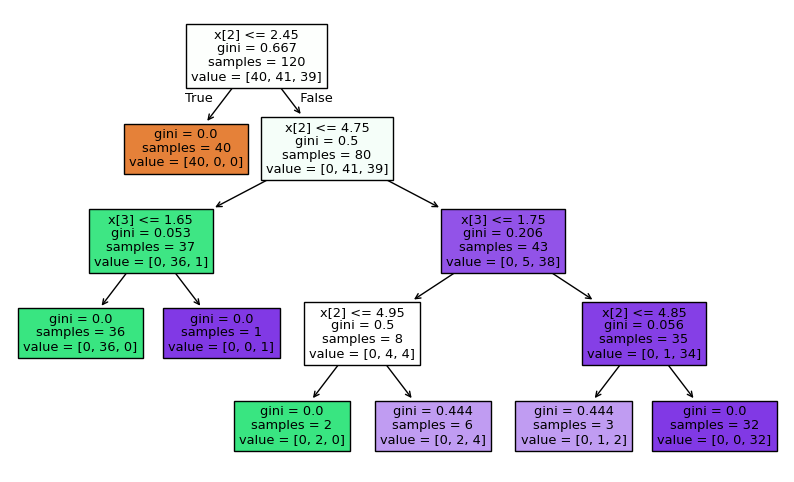

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(best_model, filled=True)
plt.show()